# Mean Monthly Global IKE Climatology

Unstacked bar chart of mean monthly IKE production, partitioned by basin --
total IKE summed per basin/month across the full period, then divided by the
number of years to get a true climatological mean.

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [5]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [6]:
import calendar

import matplotlib.pyplot as plt
import seaborn as sns

from ike_climatology import config
from ike_climatology.ibtracs_io import load_master_dataframe
from ike_climatology.style import BASIN_COLORS, DESIRED_BASIN_ORDER


## Data extraction

Uses `load_master_dataframe`'s defaults (`apply_quality_filters=True`).


In [7]:
master_df = load_master_dataframe(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")

print(f"{len(master_df)} timesteps across {master_df['storm_id'].nunique()} storms.")


--- Starting Initial Data Loading and Processing for All Basins ---
    - Loading IBTrACS data for West Pacific (2004-2024)
        Found 622 storms in file.
        - Filtered out 16 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for North Atlantic (2004-2024)
        Found 380 storms in file.
        - Filtered out 2 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for South Pacific (2004-2024)
        Found 210 storms in file.
        - Filtered out 12 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for South Indian (2004-2024)
        Found 367 storms in file.
        - Filtered out 22 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for East Pacific (2004-2024)
        Found 497 storms in file.
        - Filtered out 79 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS dat

## Figure: mean monthly IKE by basin

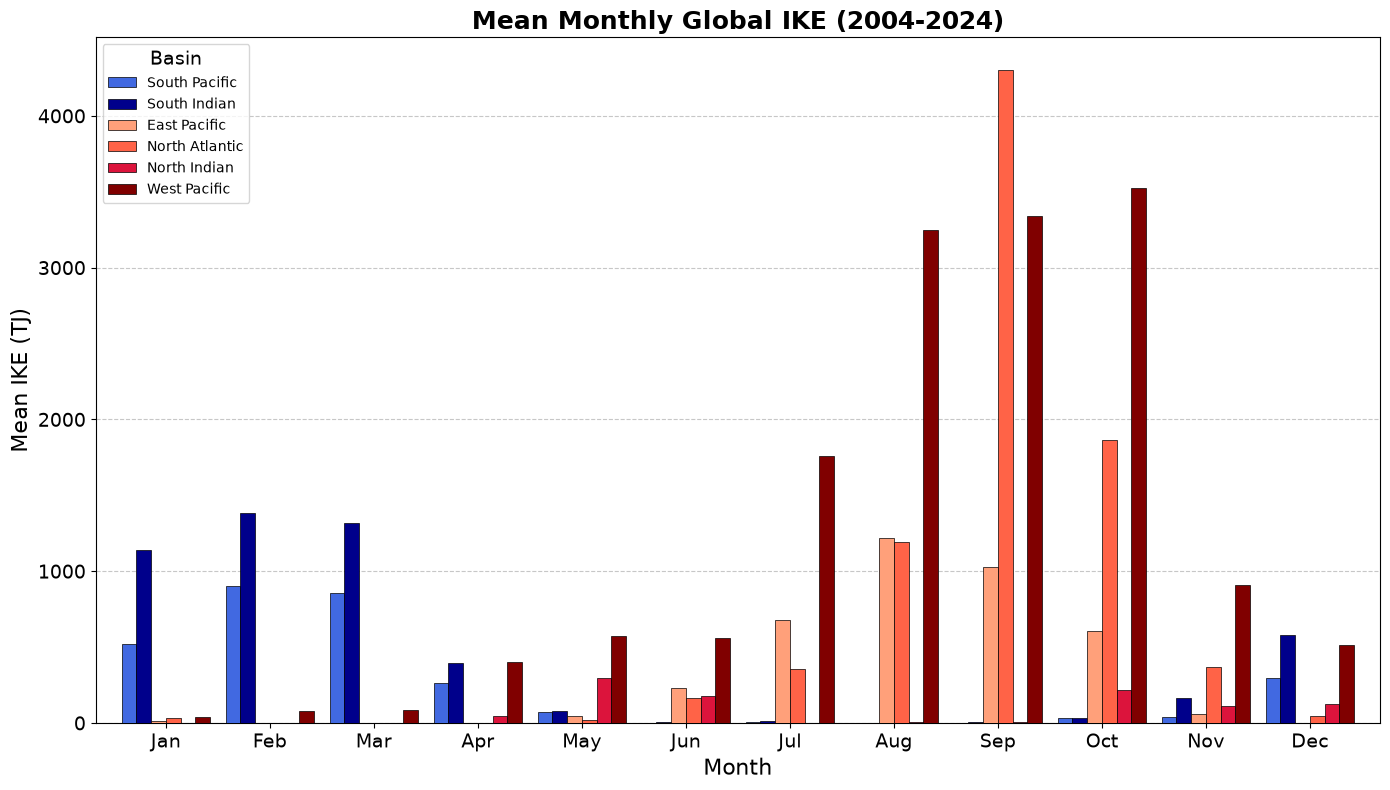

In [8]:
temp_df = master_df.copy()
temp_df["month"] = temp_df.index.month

# Sum all IKE for each basin/month across the whole period, then divide by
# the number of years to get the true climatological mean per year.
monthly_sum = temp_df.groupby(["month", "basin"])["total_ike_tj"].sum().reset_index()
num_years = temp_df["storm_year"].nunique()
monthly_sum["mean_monthly_ike"] = monthly_sum["total_ike_tj"] / num_years

df_plot = monthly_sum.pivot(index="month", columns="basin", values="mean_monthly_ike").fillna(0)
df_plot = df_plot.reindex(range(1, 13), fill_value=0)  # ensure all 12 months appear
df_plot.index = [calendar.month_abbr[m] for m in df_plot.index]

current_basins = [b for b in DESIRED_BASIN_ORDER if b in df_plot.columns]
df_plot = df_plot[current_basins]
plot_colors = [BASIN_COLORS.get(b, "gray") for b in df_plot.columns]

fig, ax = plt.subplots(figsize=(14, 8))

df_plot.plot(
    kind="bar", stacked=False, ax=ax, width=0.85,
    color=plot_colors, edgecolor="black", linewidth=0.5, zorder=5,
)

years_str = f"({config.START_YEAR}-{config.END_YEAR})"
ax.set_title(f"Mean Monthly Global IKE {years_str}", fontsize=18, weight="bold")
ax.set_xlabel("Month", fontsize=16)
ax.set_ylabel("Mean IKE (TJ)", fontsize=16)

ax.grid(True, linestyle="--", alpha=0.7, axis="y")
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.tick_params(axis="y", labelsize=14)

legend = ax.get_legend()
if legend:
    legend.set_title("Basin")
    legend.get_title().set_fontsize(14)
    for text in legend.get_texts():
        text.set_fontsize(12)
    sns.move_legend(ax, "upper left")

plt.tight_layout()
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, "monthly_climatology_unstacked_bar.png"),
            dpi=300, bbox_inches="tight")
plt.show()
